# Manual Counts

In [ ]:
!git clone https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026.git

Cloning into 'semester-project-2026'...
remote: Enumerating objects: 852, done.
remote: Counting objects: 100% (396/396), done.
remote: Compressing objects: 100% (183/183), done.
remote: Total 852 (delta 297), reused 251 (delta 209), pack-reused 456 (from 1)
Receiving objects: 100% (852/852), 13.69 MiB | 13.65 MiB/s, done.
Resolving deltas: 100% (428/428), done.
Updating files: 100% (612/612), done.


In [ ]:
# The only extra install you might need
!pip install pingouin -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.0 MB/s eta 0:00:00


In [ ]:


import pandas as pd
import pingouin as pg
from sklearn.metrics import cohen_kappa_score

In [ ]:
import glob
import os

search_path = '/content/semester-project-2026/images'
pattern = os.path.join(search_path, '**', 'student_*.csv')

found_files = glob.glob(pattern, recursive=True)

if found_files:
    print("Found 'student_*.csv' files:")
    for file_path in found_files:
        print(file_path)
else:
    print("No 'student_*.csv' files found in the specified path.")

Found 'student_*.csv' files:
/content/semester-project-2026/images/student_10/student_10_counts.csv
/content/semester-project-2026/images/student_03/student_03_counts.csv
/content/semester-project-2026/images/student_04/student_04_counts.csv
/content/semester-project-2026/images/student_06/student_06_counts.csv
/content/semester-project-2026/images/student_07/student_07_counts.csv
/content/semester-project-2026/images/student_09/student_09_counts.csv
/content/semester-project-2026/images/student_08/student_08_counts.csv
/content/semester-project-2026/images/student_05/student_05_counts.csv
/content/semester-project-2026/images/student_02/student_02_counts.csv


Load CSV

In [ ]:
import pandas as pd
import re
import os

data = []
for file_path in found_files:
    filename = os.path.basename(file_path)
    match = re.search(r'student_(\d+)_counts\.csv', filename)
    if match:
        student_number = match.group(1)
        data.append({'student_number': student_number, 'path': file_path})

student_df = pd.DataFrame(data)
display(student_df.head())

,student_number,path
0,10,/content/semester-project-2026/images/student_...
1,03,/content/semester-project-2026/images/student_...
2,04,/content/semester-project-2026/images/student_...
3,06,/content/semester-project-2026/images/student_...
4,07,/content/semester-project-2026/images/student_...


Load file mapping from blind file mixing

In [ ]:
url = 'https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026-eval/raw/refs/heads/main/tables/image_mapping_v2.csv'
image_mapping_df = pd.read_csv(url)
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate


In [ ]:
url = 'https://github.com/UCT-Advanced-Image-Analysis/semester-project-2026-eval/raw/refs/heads/main/tables/pseudo_gt_counts.csv'
pseudo_gt = pd.read_csv(url)
display(pseudo_gt.head())

,student_id,original_filename,image_name,pGT_count
0,3,11GRAY_045-cropped,img_1.tif,68
1,3,16GRAY_045-cropped,img_2.tif,43
2,3,4GRAY_045-cropped,img_3.tif,54
3,3,1GRAY_030-cropped,img_4.tif,48
4,3,13GRAY_045-cropped,img_5.tif,44


In [ ]:
image_mapping_df['original_filename'] = image_mapping_df['original_path'].apply(lambda x: x.split('/')[-1].replace('.tif', ''))
display(image_mapping_df.head())

,original_path,student_folder,new_filename,image_type,original_filename
0,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_5.tif,calibration,9GRAY_015-cropped
1,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_13.tif,calibration,16GRAY_045-cropped
2,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_14.tif,calibration,4GRAY_000-cropped
3,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_8.tif,calibration,1GRAY_030-cropped
4,/content/gdrive/MyDrive/+Projects/01_Python/02...,student_01,img_11.tif,duplicate,12GRAY_015-cropped


Load numbers from correct images

In [ ]:
student_dataframes = {}

for index, row in student_df.iterrows():
    student_number = row['student_number']
    file_path = row['path']

    # Load the CSV file, using ';' as a separator
    df_student = pd.read_csv(file_path, sep=';', header=0, index_col=None, encoding='utf-8')

    # Add the 'student_folder' column
    df_student['student_folder'] = 'student_' + student_number

    # Store the DataFrame in the dictionary
    student_dataframes[student_number] = df_student


print(f"Loaded data for {len(student_dataframes)} students.")

# Display the head of one of the student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Loaded data for 9 students.

Displaying head for student 10:


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_01,60,54,47,58,58,64,NaN,student_10
1,img_02,77,59,57,80,80,83,NaN,student_10
2,img_03,54,37,28,49,49,56,NaN,student_10
3,img_04,42,38,34,42,42,45,NaN,student_10
4,img_05,73,49,45,52,52,73,NaN,student_10


In [ ]:
import re

for student_number, df_student in student_dataframes.items():
    # Standardize image_name to match the format in image_mapping_df (e.g., 'img_1.tif' instead of 'img_01.tif')
    # First, ensure it's a string and remove any existing '.tif' for consistent processing
    df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)
    # Then, remove leading zeros from the numeric part of the image name
    df_student['image_name'] = df_student['image_name'].apply(lambda x: re.sub(r'img_0*(\d+)$', r'img_\1', x)) + '.tif'
    student_dataframes[student_number] = df_student

print("Standardized 'image_name' column formatting in all student dataframes.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for standardized student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Standardized 'image_name' column formatting in all student dataframes.

Displaying head for standardized student 10:


<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_809/2773219164.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_student['image_name'] = df_student['image_name'].astype(str).str.replace('\.tif$', '', regex=True)


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder
0,img_1.tif,60,54,47,58,58,64,NaN,student_10
1,img_2.tif,77,59,57,80,80,83,NaN,student_10
2,img_3.tif,54,37,28,49,49,56,NaN,student_10
3,img_4.tif,42,38,34,42,42,45,NaN,student_10
4,img_5.tif,73,49,45,52,52,73,NaN,student_10


In [ ]:
for student_number, df_student in student_dataframes.items():
    # Merge with image_mapping_df using 'student_folder' and 'image_name' (from df_student)
    # and 'new_filename' (from image_mapping_df)
    merged_df = pd.merge(
        df_student,
        image_mapping_df[['student_folder', 'new_filename', 'image_type', 'original_filename']],
        left_on=['student_folder', 'image_name'],
        right_on=['student_folder', 'new_filename'],
        how='left'
    )
    # Drop the redundant 'new_filename' column from the merge if it exists
    # Note: 'new_filename' is from image_mapping_df, which we don't want to keep in the final student_df
    merged_df = merged_df.drop(columns=['new_filename'])
    student_dataframes[student_number] = merged_df

print("Updated student_dataframes with image_type and original_filename.")

# Display the head of one of the updated student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for updated student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Updated student_dataframes with image_type and original_filename.

Displaying head for updated student 10:


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,60,54,47,58,58,64,NaN,student_10,unique_random,19GRAY_015-cropped
1,img_2.tif,77,59,57,80,80,83,NaN,student_10,unique_random,14GRAY_000-cropped
2,img_3.tif,54,37,28,49,49,56,NaN,student_10,unique_random,18GRAY_030-cropped
3,img_4.tif,42,38,34,42,42,45,NaN,student_10,unique_random,11GRAY_030-cropped
4,img_5.tif,73,49,45,52,52,73,NaN,student_10,unique_random,10GRAY_030-cropped


In [ ]:
df_student = student_dataframes[first_student_key]
df_student[df_student['image_type']=='calibration']

,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
5,img_6.tif,72,50,48,58,58,71,NaN,student_10,calibration,9GRAY_015-cropped
6,img_7.tif,55,42,37,46,46,55,NaN,student_10,calibration,1GRAY_030-cropped
8,img_9.tif,70,64,60,73,73,75,NaN,student_10,calibration,4GRAY_000-cropped
12,img_13.tif,58,35,33,43,43,51,NaN,student_10,calibration,16GRAY_045-cropped


In [ ]:
print("Unique 'student_folder' values in image_mapping_df:")
display(image_mapping_df['student_folder'].unique())

print("\nUnique 'student_folder' values present in student_dataframes (from keys):")
display(list(student_dataframes.keys()))

# Also check the image_name vs new_filename for a non-matching student, e.g., student_02
if '02' in student_dataframes:
    print("\nFirst 5 'image_name' values for student_02:")
    display(student_dataframes['02']['image_name'].head())

print("\nFirst 5 'new_filename' values from image_mapping_df (should ideally match student_01):")
display(image_mapping_df['new_filename'].head())

Unique 'student_folder' values in image_mapping_df:


array(['student_01', 'student_02', 'student_03', 'student_04',
       'student_05', 'student_06', 'student_07', 'student_08',
       'student_09', 'student_10'], dtype=object)


Unique 'student_folder' values present in student_dataframes (from keys):


['10', '03', '04', '06', '07', '09', '08', '05', '02']


First 5 'image_name' values for student_02:


,image_name
0,img_1.tif
1,img_2.tif
2,img_3.tif
3,img_4.tif
4,img_5.tif



First 5 'new_filename' values from image_mapping_df (should ideally match student_01):


,new_filename
0,img_5.tif
1,img_13.tif
2,img_14.tif
3,img_8.tif
4,img_11.tif


In [ ]:
for student_number, df_student in student_dataframes.items():
    # Drop the redundant _x columns which are mostly NaN for the merged data
    df_student = df_student.drop(columns=['image_type_x', 'original_filename_x'], errors='ignore')

    # Rename the _y columns to their original names
    df_student = df_student.rename(columns={
        'image_type_y': 'image_type',
        'original_filename_y': 'original_filename'
    })
    student_dataframes[student_number] = df_student

print("Cleaned up merged columns in all student dataframes.")

# Display the head of one of the cleaned student dataframes as an example
if student_dataframes:
    first_student_key = list(student_dataframes.keys())[0]
    print(f"\nDisplaying head for cleaned student {first_student_key}:")
    display(student_dataframes[first_student_key].head())

Cleaned up merged columns in all student dataframes.

Displaying head for cleaned student 10:


,image_name,manual_count,script_own,script_simple,script_watershed 1,script_own_sparse,script_SarDist,YOLO_count,student_folder,image_type,original_filename
0,img_1.tif,60,54,47,58,58,64,NaN,student_10,unique_random,19GRAY_015-cropped
1,img_2.tif,77,59,57,80,80,83,NaN,student_10,unique_random,14GRAY_000-cropped
2,img_3.tif,54,37,28,49,49,56,NaN,student_10,unique_random,18GRAY_030-cropped
3,img_4.tif,42,38,34,42,42,45,NaN,student_10,unique_random,11GRAY_030-cropped
4,img_5.tif,73,49,45,52,52,73,NaN,student_10,unique_random,10GRAY_030-cropped


## Prepare Data for Visualization

Consolidate data from all `student_dataframes` for `image_type == 'calibration'`, extracting `manual_count`, `original_filename`, and `student_number`.


In [ ]:
calibration_data_list = []

for student_number, df_student in student_dataframes.items():
    # Filter for 'calibration' image_type
    calibration_df_student = df_student[df_student['image_type'] == 'calibration'].copy()

    # Select relevant columns and add student_number
    if not calibration_df_student.empty:
        calibration_df_student = calibration_df_student[['manual_count', 'original_filename']]
        calibration_df_student['student_number'] = student_number
        calibration_data_list.append(calibration_df_student)
        print(student_number)

# Concatenate all DataFrames in the list into a single DataFrame
if calibration_data_list:
    calibration_df = pd.concat(calibration_data_list, ignore_index=True)
    print(f"Consolidated calibration data for {len(calibration_data_list)} students. Total rows: {len(calibration_df)}")
    display(calibration_df.head())
else:
    print("No calibration data found for any student.")
    calibration_df = pd.DataFrame()

10
03
04
07
09
08
05
02
Consolidated calibration data for 8 students. Total rows: 32


,manual_count,original_filename,student_number
0,72,9GRAY_015-cropped,10
1,55,1GRAY_030-cropped,10
2,70,4GRAY_000-cropped,10
3,58,16GRAY_045-cropped,10
4,53,16GRAY_045-cropped,03


In [ ]:
calibration_df['original_filename'].unique()

array(['9GRAY_015-cropped', '1GRAY_030-cropped', '4GRAY_000-cropped',
       '16GRAY_045-cropped'], dtype=object)

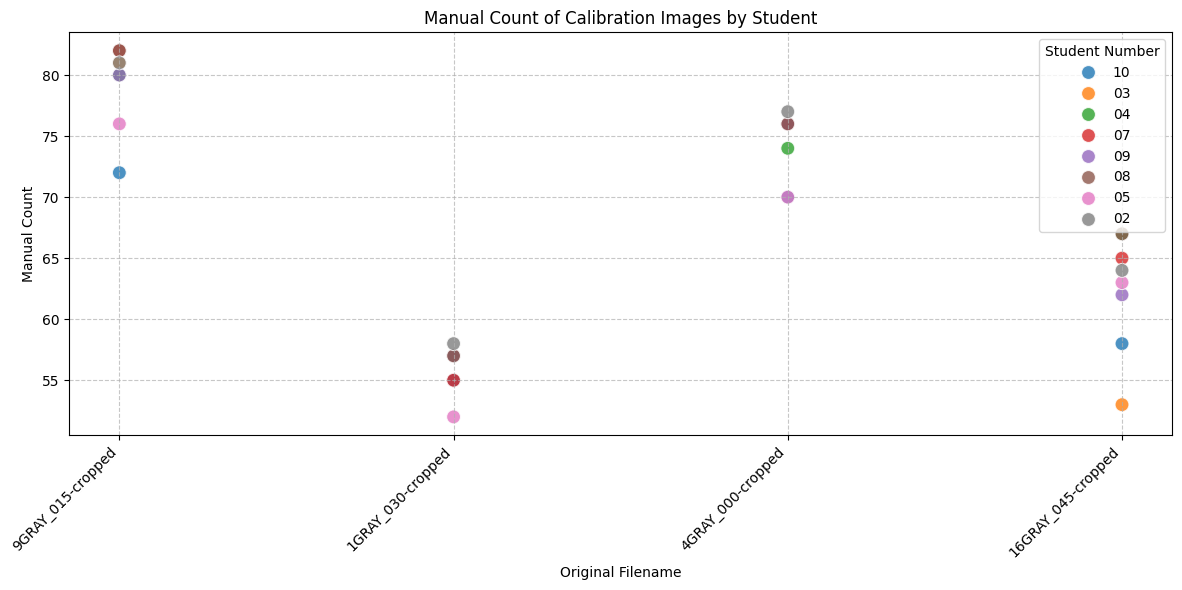

Generated scatter plot of manual counts for calibration images.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=calibration_df,
    x='original_filename',
    y='manual_count',
    hue='student_number',
    s=100,  # size of the points
    alpha=0.8
)
plt.title('Manual Count of Calibration Images by Student')
plt.xlabel('Original Filename')
plt.ylabel('Manual Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Student Number')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Generated scatter plot of manual counts for calibration images.")

Create a box plot showing the distribution of `manual_count` for 'calibration' images, grouped by `original_filename`, as specified in the main task. I will use `seaborn` for this visualization.



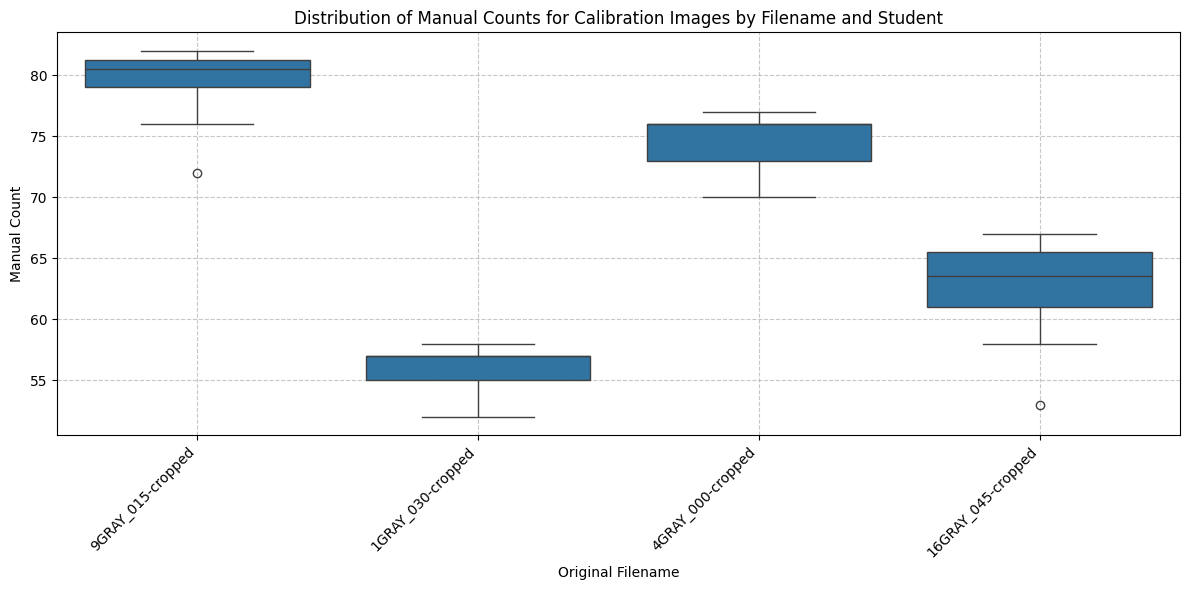

Generated box plot of manual counts for calibration images.


In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=calibration_df,
    x='original_filename',
    y='manual_count',
)
plt.title('Distribution of Manual Counts for Calibration Images by Filename and Student')
plt.xlabel('Original Filename')
plt.ylabel('Manual Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('boxplot_manual_counts_calibration.png')
plt.show()

print("Generated box plot of manual counts for calibration images.")

# Task
Prepare a single dataframe containing `script_simple`, `original_filename`, and `student_number` for all entries where `image_type` is 'calibration' from the `student_dataframes`.

## Prepare Data for Visualization (script_simple)

### Subtask:
Consolidate data from all `student_dataframes` for `image_type == 'calibration'`, extracting `script_simple` and `original_filename`. Also, prepare the data such that `student_number` can be used as a distinct identifier if needed for grouping in plots.


**Reasoning**:
The subtask requires consolidating calibration data with `script_simple` counts from all student dataframes into a single dataframe. The code will iterate through each student's dataframe, filter for 'calibration' image types, select the required columns (`script_simple`, `original_filename`), add the `student_number`, and then concatenate all these individual dataframes into a final `script_simple_calibration_df`.



In [ ]:
script_simple_calibration_data_list = []

for student_number, df_student in student_dataframes.items():
    # Filter for 'calibration' image_type
    calibration_df_student = df_student[df_student['image_type'] == 'calibration'].copy()
    print(student_number)

    # Select relevant columns and add student_number
    if not calibration_df_student.empty:
        # Ensure 'script_simple' column exists before trying to access it
        if 'script_simple' in calibration_df_student.columns:
            calibration_df_student = calibration_df_student[['script_simple', 'original_filename']]
            calibration_df_student['student_number'] = student_number
            script_simple_calibration_data_list.append(calibration_df_student)
        else:
            print(f"Warning: 'script_simple' column not found for student {student_number}")

# Concatenate all DataFrames in the list into a single DataFrame
if script_simple_calibration_data_list:
    script_simple_calibration_df = pd.concat(script_simple_calibration_data_list, ignore_index=True)
    print(f"Consolidated calibration data for {len(script_simple_calibration_data_list)} students. Total rows: {len(script_simple_calibration_df)}")
    display(script_simple_calibration_df.head())
else:
    print("No calibration data with 'script_simple' found for any student.")
    script_simple_calibration_df = pd.DataFrame()

10
03
04
06
07
09
08
05
02
Consolidated calibration data for 8 students. Total rows: 32


,script_simple,original_filename,student_number
0,48,9GRAY_015-cropped,10
1,37,1GRAY_030-cropped,10
2,60,4GRAY_000-cropped,10
3,33,16GRAY_045-cropped,10
4,43,16GRAY_045-cropped,03


## Calculate Descriptive Statistics for Manual Counts


Calculate the mean, standard deviation, min, and max of `manual_count` for each `original_filename` to understand the variability across students for each calibration image.


In [ ]:
descriptive_stats_manual_counts = calibration_df.groupby('original_filename')['manual_count'].agg(['mean', 'std', 'min', 'max'])
display(descriptive_stats_manual_counts)
print("Calculated descriptive statistics for manual counts per original filename.")

,mean,std,min,max
original_filename,,,,
16GRAY_045-cropped,62.375,4.779047,53,67
1GRAY_030-cropped,56.000,1.927248,52,58
4GRAY_000-cropped,74.375,2.825269,70,77
9GRAY_015-cropped,79.250,3.494894,72,82


Calculated descriptive statistics for manual counts per original filename.


To prepare the data for Intraclass Correlation Coefficient (ICC) calculation, I will reshape the `calibration_df` into a wide format where `original_filename` are rows, `student_number` are columns, and `manual_count` are values. This is typically done using the `pivot_table` function.



In [ ]:
calibration_pivot_df = calibration_df.pivot_table(index='original_filename', columns='student_number', values='manual_count')
display(calibration_pivot_df)
print("Reshaped calibration_df into a wide format (calibration_pivot_df).")

student_number,02,03,04,05,07,08,09,10
original_filename,,,,,,,,
16GRAY_045-cropped,64.0,53.0,67.0,63.0,65.0,67.0,62.0,58.0
1GRAY_030-cropped,58.0,57.0,57.0,52.0,55.0,57.0,57.0,55.0
4GRAY_000-cropped,77.0,76.0,74.0,70.0,76.0,76.0,76.0,70.0
9GRAY_015-cropped,81.0,81.0,80.0,76.0,82.0,82.0,80.0,72.0


Reshaped calibration_df into a wide format (calibration_pivot_df).



To compute the Intraclass Correlation Coefficient (ICC) for absolute agreement between the students' manual counts, I will use the `pingouin` library. The `calibration_pivot_df` is already in a wide format suitable for `pg.icc` function, which expects subjects as index and raters as columns. I will use a two-way random effects model (`model='twoway'`) and absolute agreement (`type='agreement'`) to evaluate the consistency of manual counts across students for each original filename.



In [ ]:
icc_manual_counts = pg.intraclass_corr(data=calibration_df, targets='original_filename', raters='student_number', ratings='manual_count')
print("Intraclass Correlation Coefficient (ICC) for Manual Counts:")
display(icc_manual_counts)
print("Calculated ICC for manual counts using a two-way random effects model and absolute agreement.")
icc_manual_counts.to_csv('icc_manual_counts.csv', index=False)

Intraclass Correlation Coefficient (ICC) for Manual Counts:


,Type,ICC,F,df1,df2,pval,CI95
0,"ICC(1,1)",0.906130,78.224599,3,28,1.005777e-13,"[0.72, 0.99]"
1,"ICC(A,1)",0.906524,122.093800,3,21,1.888342e-13,"[0.71, 0.99]"
2,"ICC(C,1)",0.938030,122.093800,3,21,1.888342e-13,"[0.79, 1.0]"
3,"ICC(1,k)",0.987216,78.224599,3,28,1.005777e-13,"[0.95, 1.0]"
4,"ICC(A,k)",0.987275,122.093800,3,21,1.888342e-13,"[0.95, 1.0]"
5,"ICC(C,k)",0.991810,122.093800,3,21,1.888342e-13,"[0.97, 1.0]"


Calculated ICC for manual counts using a two-way random effects model and absolute agreement.


In [ ]:
# Calculate the Coefficient of Variation (CV) for manual_count for each original_filename
# CV = (Standard Deviation / Mean) * 100
cv_manual_counts = calibration_df.groupby('original_filename').agg(
    mean_count=('manual_count', 'mean'),
    std_count=('manual_count', 'std')
).reset_index()
cv_manual_counts['cv_percentage'] = (cv_manual_counts['std_count'] / cv_manual_counts['mean_count']) * 100

print("Coefficient of Variation for Manual Counts per Image:")
display(cv_manual_counts)
cv_manual_counts.to_csv('cv_manual_counts.csv', index=False)

Coefficient of Variation for Manual Counts per Image:


,original_filename,mean_count,std_count,cv_percentage
0,16GRAY_045-cropped,62.375,4.779047,7.661798
1,1GRAY_030-cropped,56.000,1.927248,3.441515
2,4GRAY_000-cropped,74.375,2.825269,3.798681
3,9GRAY_015-cropped,79.250,3.494894,4.409961


A lower Coefficient of Variation indicates less relative variability (more agreement) among the student's counts for that particular image. Let's visualize these CVs.

/tmp/ipykernel_809/939501525.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


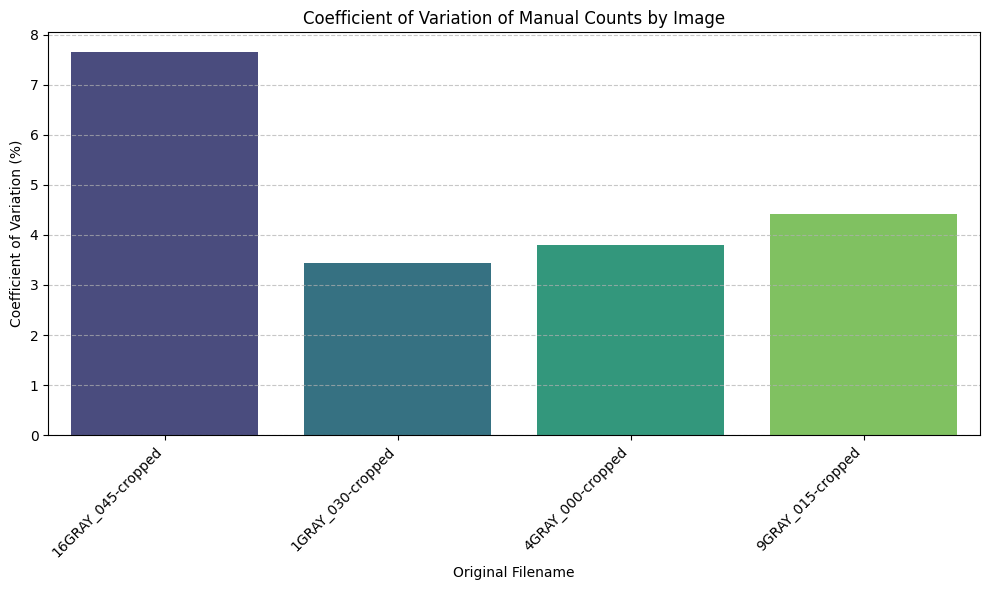

Generated bar plot of Coefficient of Variation for manual counts.


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=cv_manual_counts,
    x='original_filename',
    y='cv_percentage',
    palette='viridis'
)
plt.title('Coefficient of Variation of Manual Counts by Image')
plt.xlabel('Original Filename')
plt.ylabel('Coefficient of Variation (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('barplot_cv_manual_counts.png')
plt.show()

print("Generated bar plot of Coefficient of Variation for manual counts.")